# Viewing the dataset

This notebook demonstrates how to access metadata and arrays from the HDF5 dataset.

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# Open the dataset

Make sure to update the filepath in the block below!

In [ ]:
h5_filepath = '/data/bwedig/mejiro/roman_data_challenge_rung_1/06/roman_data_challenge_rung_1_v_1_0.h5'  # TODO update this path!
f = h5py.File(h5_filepath, 'r')

In [ ]:
# print all attributes for the root group
for key, value in f.attrs.items():
    print(f"{key}: {value}")

author: ['bwedig@europa.physics.wustl.edu' 'username@host for calculation']
created: 2026_04_25-09_06_00_PM
dataset_version: 0.1
lenstronomy_version: ['1.13.3' 'lenstronomy version']
mejiro_version: ['3.0.0' 'mejiro version']
romanisim_version: ['0.13.0' 'romanisim version']
slsim_version: ['0.1.1' 'SLSim version']
stpsf_version: ['2.1.0' 'STPSF version']


# The `images` group

This group contains metadata about each strong lens system (e.g., redshifts, Einstein radius, SNR, etc.) and synthetic images and exposures for each filter.

## Retrieve the metadata for a given system

In [ ]:
# select a system by the unique identifier assigned to it by mejiro
uid = f'{str(5).zfill(8)}'  # for this version of the dataset, it's a zero-padded string of eight digits

# print all attributes for the "strong_lens" group
for key, value in f['images'][f'strong_lens_{uid}'].attrs.items():
    print(f"{key}: {value}")

detector: ['1' 'Detector']
detector_position_x: ['1532' 'Detector X position']
detector_position_y: ['2554' 'Detector Y position']
substructure: ['False' 'Is substructure present in this lens?']
uid: ['00000005' 'Unique identifier for system assigned by mejiro']
z_lens: ['0.1379999999999999' 'Lens galaxy redshift']
z_source: ['1.3703617086533608' 'Source galaxy redshift']


In [ ]:
from tqdm import tqdm
import sys

with_substructure, smooth = [], []

for name, group in tqdm(f['images'].items()):
    if not name.startswith('strong_lens_'):
        continue

    uid = name.split('_')[-1]

    image = group[f'exposure_{uid}_F129'][:]
    substructure_flag = group.attrs['substructure'][0]

    if substructure_flag == 'True':
        with_substructure.append(image)
    elif substructure_flag == 'False':
        smooth.append(image)
    else:
        raise ValueError(f"Unexpected substructure flag: {substructure_flag}")

100%|██████████| 107389/107389 [02:04<00:00, 865.99it/s] 


In [ ]:
print(f"Number of systems with substructure: {len(with_substructure)}")
print(f"Number of systems without substructure: {len(smooth)}")

Number of systems with substructure: 53636
Number of systems without substructure: 53753


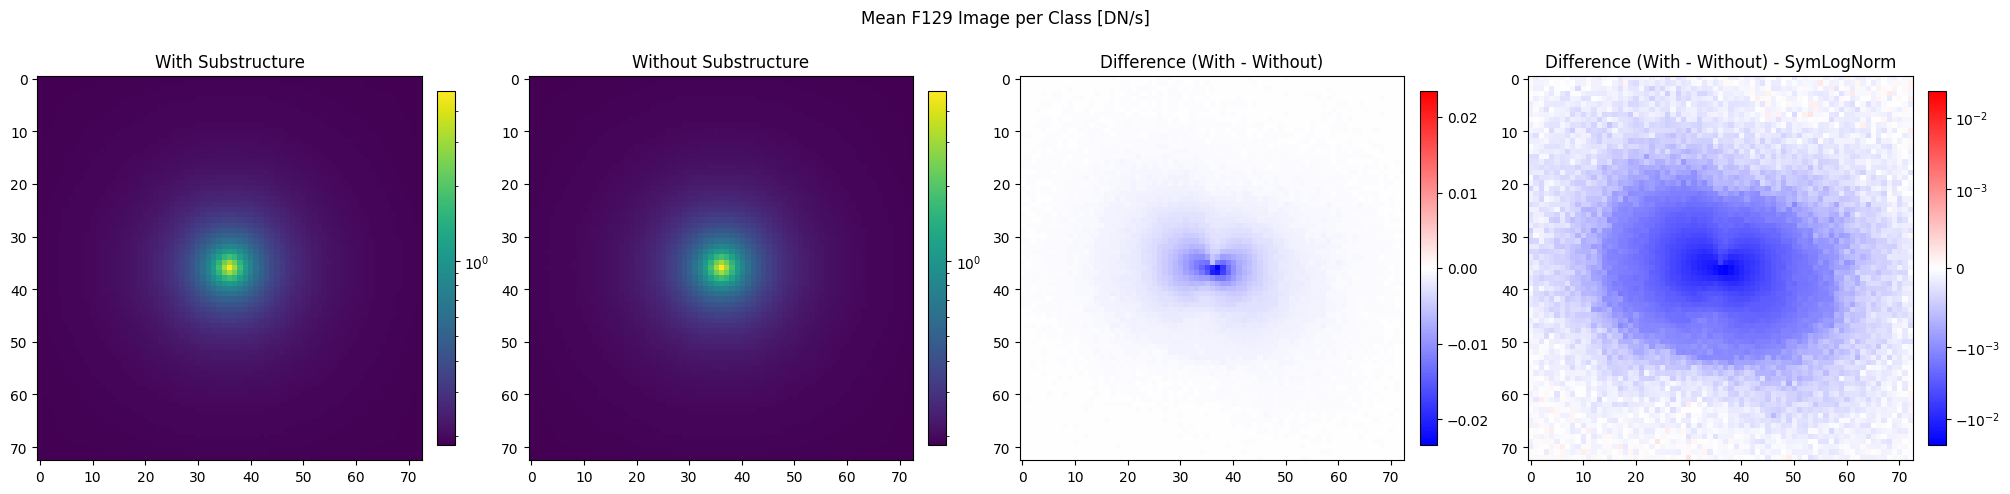

In [ ]:
from matplotlib.colors import LogNorm, CenteredNorm, SymLogNorm

mean_with = np.mean(with_substructure, axis=0)
mean_smooth = np.mean(smooth, axis=0)
diff = mean_with - mean_smooth
abs_max = np.max(np.abs(diff))

fig, ax = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)
im0 = ax[0].imshow(mean_with, norm=LogNorm())
im1 = ax[1].imshow(mean_smooth, norm=LogNorm())
im2 = ax[2].imshow(diff, norm=CenteredNorm(), cmap='bwr')
im3 = ax[3].imshow(diff, norm=SymLogNorm(linthresh=1e-3, vmin=-abs_max, vmax=abs_max), cmap='bwr')

ax[0].set_title('With Substructure')
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

ax[1].set_title('Without Substructure')
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

ax[2].set_title('Difference (With - Without)')
fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

ax[3].set_title('Difference (With - Without) - SymLogNorm')
fig.colorbar(im3, ax=ax[3], fraction=0.046, pad=0.04)

plt.suptitle('Mean F129 Image per Class [DN/s]')
plt.savefig('mean_f129_comparison.png', dpi=300)
plt.show()

## View synthetic image and exposure

In [ ]:
# specify band
band = 'F129'

# retrieve
exposure = f['images'][f'strong_lens_{uid}'][f'exposure_{uid}_{band}']
synthetic_image = f['images'][f'strong_lens_{uid}'][f'synthetic_image_{uid}_{band}']

# print all attributes for these datasets
print('Exposure dataset:')
for key, value in exposure.attrs.items():
    print(f"{key}: {value}")

print('\nSynthetic image dataset:')
for key, value in synthetic_image.attrs.items():
    print(f"{key}: {value}")

KeyError: "Unable to synchronously open object (object 'synthetic_image_00000005_F129' doesn't exist)"

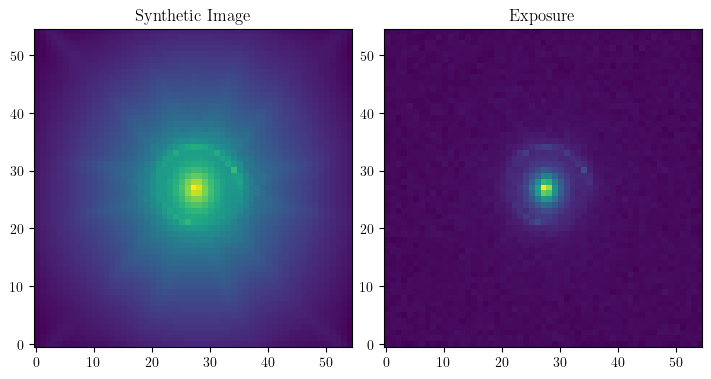

In [ ]:
_, ax = plt.subplots(1, 2)
ax[0].imshow(np.log10(synthetic_image))
ax[0].set_title('Synthetic Image')
ax[1].imshow(np.log10(exposure))
ax[1].set_title('Exposure')
plt.show()

# The `psfs` group

This group contains the PSFs

## View a PSF

We'll retrieve the PSF associated with the image we looked at above.

In [ ]:
# retrieve the detector and detector position metadata, which are attributes on the "strong_lens" group
detector = f['images'][f'strong_lens_{uid}'].attrs['detector'][0]
detector_position_x = f['images'][f'strong_lens_{uid}'].attrs['detector_position_x'][0]
detector_position_y = f['images'][f'strong_lens_{uid}'].attrs['detector_position_y'][0]

print(f"Detector: {detector}")
print(f"Detector Position (x): {detector_position_x}")
print(f"Detector Position (y): {detector_position_y}")

Detector: 1
Detector Position (x): 1226
Detector Position (y): 2044


detector: ['1' 'Detector']
detector_position_x: ['1226' 'Detector X position']
detector_position_y: ['2044' 'Detector Y position']
fov_pixels: ['101' 'See STPSF documentation']
oversample: ['1' 'See STPSF documentation']


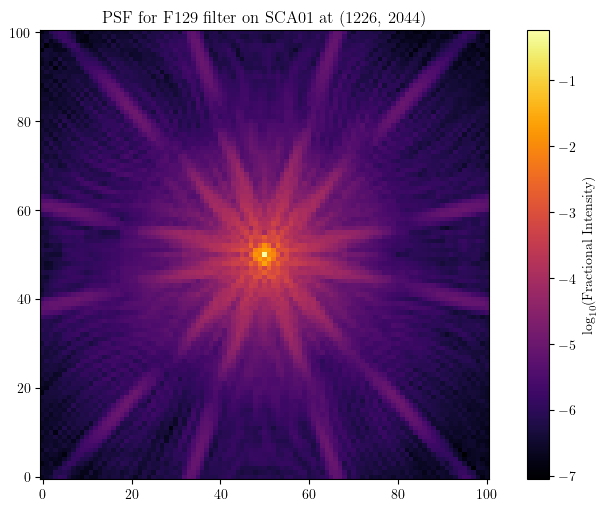

In [ ]:
# retrieve the PSF
psf = f['psfs'][f'sca{str(detector).zfill(2)}'][f'psf_{band}_{detector}_{detector_position_x}_{detector_position_y}_1_101']

# print all attributes for this dataset
for key, value in psf.attrs.items():
    print(f"{key}: {value}")

# show PSF
plt.imshow(np.log10(psf), cmap='inferno')
plt.colorbar(label=r'$\log_{10}(\text{Fractional Intensity})$')
plt.title(f'PSF for {band} filter on SCA{str(detector).zfill(2)} at ({detector_position_x}, {detector_position_y})')
plt.show()